# 06 — November 2018 hourly resolution case study and observed validation

This is a **one-month hourly case study**, not a full-year hourly analysis. It reads only committed compact artifacts and compares COSMO-REA6 area-weighted resource and capacity-weighted modelled fleet proxies with SMARD observed national grid-fed generation.

**Result to keep in view:** solar hourly timing and ramps are reproduced strongly, whereas wind ramp correlation is much weaker. Capacity weighting improves some wind and hybrid metrics but does not solve the wind-ramp problem. The preserved hourly-versus-daily comparison also demonstrates that nonlinear wind conversion and temporal averaging do not commute.

SMARD is the primary national observational reference; OPSD supplies spatial installed-capacity weights, not generation observations. OPSD time series are not treated as independent validation because provenance may overlap operational sources.

## Provenance, units, denominator, and clock

SMARD filters 4067 (onshore wind) and 4068 (PV) provide MWh in each one-hour interval; attribution: **Bundesnetzagentur | SMARD.de, CC BY 4.0**, underlying data received from ENTSO-E. CF divides MWh by fixed end-2018 capacity (52,565 MW wind; 45,277 MW solar) times 1 h. This static denominator slightly understates CF when capacity was lower; correlation and ramp timing are less affected than level. Observed hybrid CF is `0.5 wind + 0.5 solar`: a hypothetical equal-rated-capacity portfolio, not actual combined national generation.

COSMO labels hours ending from 2018-11-01 01:00 through 2018-12-01 00:00 UTC. We subtract one hour and match SMARD **in UTC**, never by Berlin wall time. Numerically, COSMO `2018-11-01 01:00` → interval start `2018-11-01 00:00 UTC` → Berlin display `2018-11-01T01:00:00+01:00`. November has no DST transition, but clocks remain distinct.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd(); A=ROOT/'app_assets'/'2018'
aligned=pd.read_parquet(A/'cosmo_smard_de_201811_hourly_validation.parquet')
with open(A/'cosmo_smard_de_201811_hourly_validation_qc.json',encoding='utf-8') as f: vqc=json.load(f)
with open(A/'cosmo_rea6_de_201811_hourly_qc.json',encoding='utf-8') as f: cqc=json.load(f)
aligned['interval_start_utc']=pd.to_datetime(aligned.interval_start_utc)
pd.Series({'COSMO rows':720,'SMARD rows':vqc['records'],'exact UTC matches':vqc['exact_matches'],'missing COSMO':vqc['missing_cosmo'],'missing SMARD':vqc['missing_smard'],'duplicates':vqc['duplicates'],'first':vqc['start_interval_start_utc'],'last':vqc['end_interval_start_utc']},name='QC')

COSMO rows                           720
SMARD rows                           720
exact UTC matches                    720
missing COSMO                          0
missing SMARD                          0
duplicates                             0
first                2018-11-01 00:00:00
last                 2018-11-30 23:00:00
Name: QC, dtype: object

## Hourly versus daily processing routes

Nonlinear weather-to-CF conversion applied hourly and then averaged need not equal conversion of daily-mean weather. The COSMO QC summary below compares those two processing routes; it is resolution sensitivity, not observation skill.

In [2]:
pd.DataFrame(cqc['daily_vs_existing_daily']['metrics']).T.round(4)

,n_days,correlation,bias,mae,rmse
wind_area,30.0,0.9927,0.0306,0.0306,0.0348
wind_capacity,30.0,0.9931,0.0326,0.0326,0.0388
solar_area,30.0,1.0000,-0.0002,0.0002,0.0003
solar_capacity,30.0,1.0000,-0.0002,0.0002,0.0003
hybrid_area,30.0,0.9924,0.0152,0.0152,0.0173
hybrid_capacity,30.0,0.9927,0.0162,0.0162,0.0193


## Observed and modelled hourly trajectories

Area weighting describes Germany's land resource; OPSD capacity weighting emphasizes mapped 2018 fleet locations. Both remain generic model proxies.

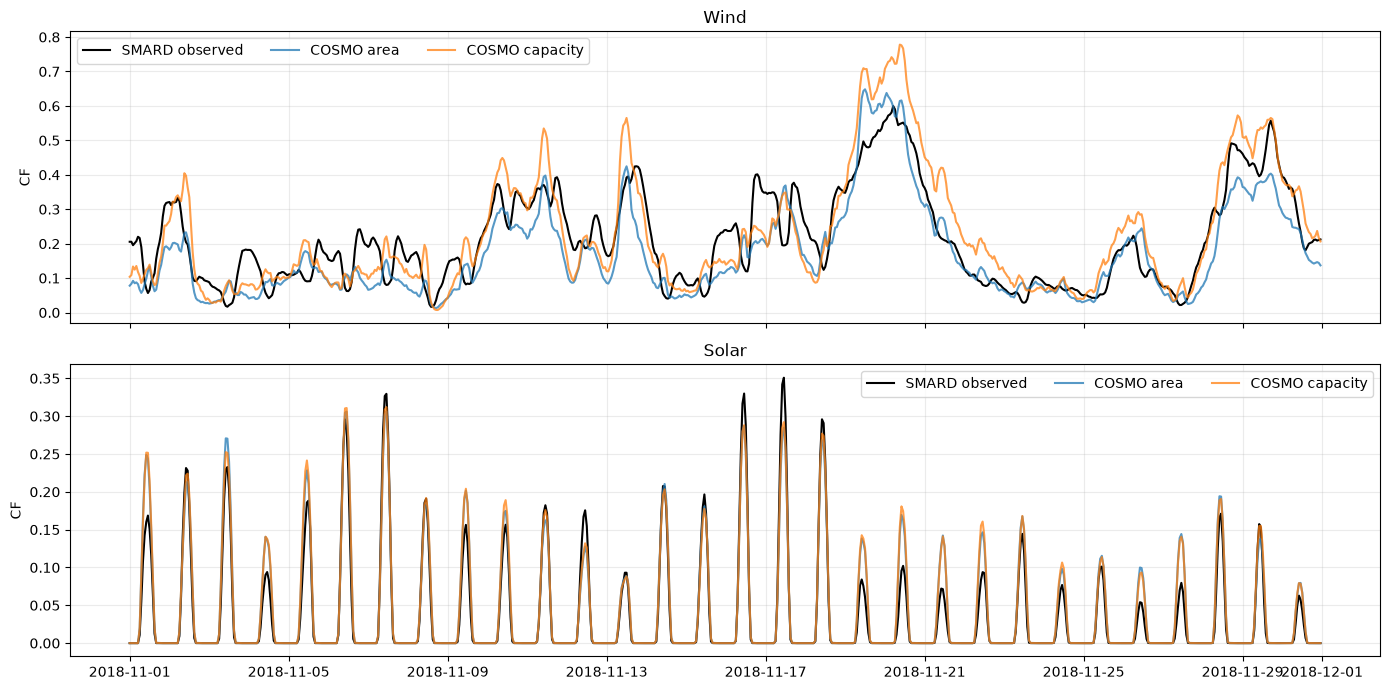

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True)
for ax,t in zip(axes,['wind','solar']):
 ax.plot(aligned.interval_start_utc,aligned[f'observed_{t}_cf'],label='SMARD observed',c='black',lw=1.5)
 ax.plot(aligned.interval_start_utc,aligned[f'{t}_cf_area'],label='COSMO area',alpha=.75)
 ax.plot(aligned.interval_start_utc,aligned[f'{t}_cf_capacity'],label='COSMO capacity',alpha=.75)
 ax.set(title=t.title(),ylabel='CF'); ax.grid(alpha=.25); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

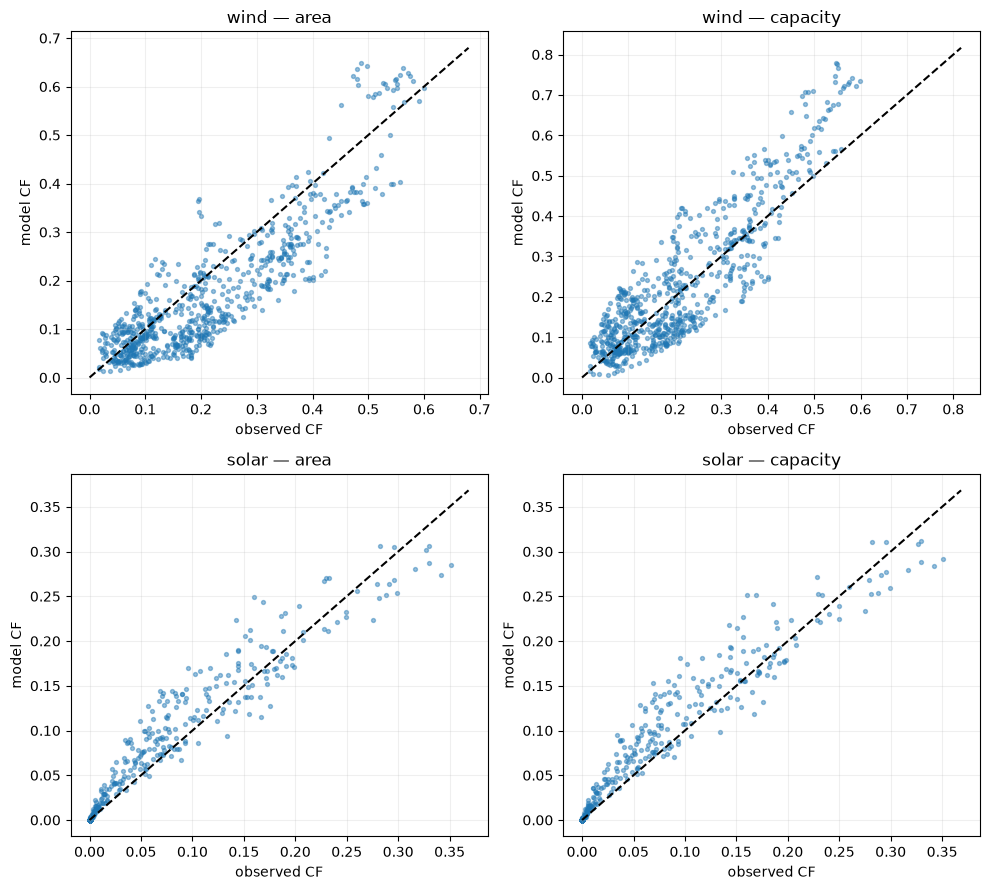

In [4]:
fig,axes=plt.subplots(2,2,figsize=(10,9))
for i,t in enumerate(['wind','solar']):
 for j,w in enumerate(['area','capacity']):
  ax=axes[i,j]; ax.scatter(aligned[f'observed_{t}_cf'],aligned[f'{t}_cf_{w}'],s=8,alpha=.45)
  lim=max(ax.get_xlim()[1],ax.get_ylim()[1]); ax.plot([0,lim],[0,lim],'k--'); ax.set(xlabel='observed CF',ylabel='model CF',title=f'{t} — {w}'); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## Level and timing metrics

Correlation primarily describes co-timing and shape; bias/MAE/RMSE describe amplitude error. High correlation does not imply an unbiased level. No observed values were used for fitting, rescaling, calibration, or threshold tuning.

In [5]:
rows=[]
for w,d in vqc['validation_metrics'].items():
 for t,m in d.items(): rows.append({'weighting':w,'technology':t,**m})
pd.DataFrame(rows).set_index(['weighting','technology']).round(4)

n  observed_mean  model_mean  correlation  \
weighting technology                                                
area      wind        720         0.2110      0.1708       0.8767   
          solar       720         0.0356      0.0410       0.9680   
          hybrid      720         0.1233      0.1059       0.8796   
capacity  wind        720         0.2110      0.2273       0.8855   
          solar       720         0.0356      0.0417       0.9685   
          hybrid      720         0.1233      0.1345       0.8991   

                      bias_model_minus_observed     mae    rmse  
weighting technology                                             
area      wind                          -0.0402  0.0636  0.0784  
          solar                          0.0053  0.0088  0.0184  
          hybrid                        -0.0174  0.0339  0.0411  
capacity  wind                           0.0163  0.0656  0.0817  
          solar                          0.0061  0.0088  0.0188  
          hybrid                         0.0112  0.0358  0.0454

## Ramp validation

Ramps are first differences over consecutive UTC hours only (719 pairs); no difference is taken across a gap. Ramp correlation evaluates transition timing/shape, while ramp bias and errors evaluate change amplitude. The results below intentionally foreground the contrast: solar ramps track observations closely, while wind ramp correlation is weak under both weighting methods.

In [6]:
rows=[]
for w,d in vqc['ramp_validation'].items():
 for t,m in d.items(): rows.append({'weighting':w,'technology':t,**m})
pd.DataFrame(rows).set_index(['weighting','technology']).round(4)

n_ramps  observed_mean_ramp  model_mean_ramp  \
weighting technology                                                 
area      wind            719                 0.0           0.0001   
          solar           719                 0.0           0.0000   
          hybrid          719                 0.0           0.0000   
capacity  wind            719                 0.0           0.0001   
          solar           719                 0.0           0.0000   
          hybrid          719                 0.0           0.0001   

                      ramp_correlation  ramp_bias_model_minus_observed  \
weighting technology                                                     
area      wind                  0.1810                          0.0001   
          solar                 0.9637                         -0.0000   
          hybrid                0.7971                          0.0000   
capacity  wind                  0.2371                          0.0001   
          solar                 0.9638                         -0.0000   
          hybrid                0.8024                          0.0001   

                      ramp_mae  ramp_rmse  
weighting technology                       
area      wind          0.0151     0.0214  
          solar         0.0040     0.0076  
          hybrid        0.0084     0.0119  
capacity  wind          0.0166     0.0233  
          solar         0.0040     0.0077  
          hybrid        0.0092     0.0130

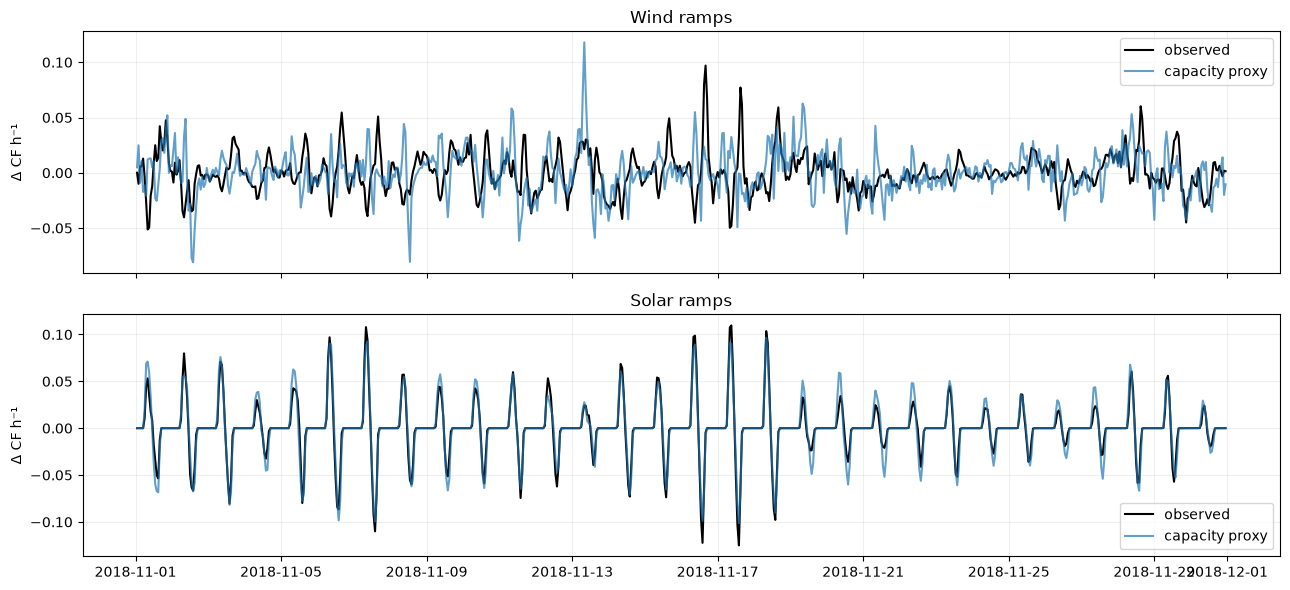

In [7]:
fig,axes=plt.subplots(2,1,figsize=(13,6),sharex=True)
for ax,t in zip(axes,['wind','solar']):
 ax.plot(aligned.interval_start_utc,aligned[f'observed_{t}_cf'].diff(),label='observed',c='black')
 ax.plot(aligned.interval_start_utc,aligned[f'{t}_cf_capacity'].diff(),label='capacity proxy',alpha=.7)
 ax.set(ylabel='Δ CF h⁻¹',title=f'{t.title()} ramps'); ax.grid(alpha=.2); ax.legend()
plt.tight_layout(); plt.show()

## Solar daylight and night

Two transparent definitions are reported rather than silently choosing one: observed daylight is SMARD PV generation >1 MWh; model daylight is GHI >0 W m⁻². SMARD can contain tiny nonzero nighttime PV values, plausibly reflecting operational reporting/aggregation effects; they should not be interpreted as solar irradiance. For the model-defined night subset the model solar CF is identically zero, so a correlation is mathematically undefined and is shown as "undefined".

In [8]:
display(pd.Series(vqc['solar_daylight_night']['counts']))
daylight = pd.concat({w: pd.DataFrame(x).T for w, x in vqc['solar_daylight_night']['metrics'].items()}).round(5)
daylight.astype(object).where(daylight.notna(), "undefined (model = 0)")

observed_daylight                    302
observed_night                       418
area_model_daylight                  363
capacity_model_daylight              363
tiny_nonzero_observed_night_hours    418
dtype: int64

n observed_mean model_mean  \
area     observed_definition_daylight  302.0       0.08497     0.0977   
         observed_definition_night     418.0       0.00002    0.00003   
         model_definition_daylight     363.0       0.07069    0.08131   
         model_definition_night        357.0       0.00001        0.0   
capacity observed_definition_daylight  302.0       0.08497    0.09947   
         observed_definition_night     418.0       0.00002    0.00003   
         model_definition_daylight     363.0       0.07069    0.08278   
         model_definition_night        357.0       0.00001        0.0   

                                                 correlation  \
area     observed_definition_daylight                  0.951   
         observed_definition_night                   0.33018   
         model_definition_daylight                   0.95743   
         model_definition_night        undefined (model = 0)   
capacity observed_definition_daylight                0.95208   
         observed_definition_night                   0.32953   
         model_definition_daylight                   0.95824   
         model_definition_night        undefined (model = 0)   

                                      bias_model_minus_observed      mae  \
area     observed_definition_daylight                   0.01273  0.02094   
         observed_definition_night                      0.00001  0.00004   
         model_definition_daylight                      0.01062  0.01745   
         model_definition_night                        -0.00001  0.00001   
capacity observed_definition_daylight                    0.0145  0.02099   
         observed_definition_night                      0.00001  0.00004   
         model_definition_daylight                      0.01209   0.0175   
         model_definition_night                        -0.00001  0.00001   

                                          rmse  
area     observed_definition_daylight  0.02841  
         observed_definition_night     0.00008  
         model_definition_daylight     0.02591  
         model_definition_night        0.00001  
capacity observed_definition_daylight  0.02905  
         observed_definition_night     0.00008  
         model_definition_daylight     0.02649  
         model_definition_night        0.00001

## Hybrid low-output classification and contiguous runs

The observed and model hypothetical equal-rated-capacity hybrid threshold is CF < 0.10. Confusion counts, precision, recall, agreement, and run summaries compare low-output screening classifications. Nighttime solar zeros naturally influence contiguous hourly runs, so these are not equivalent to the ≥2-day daily event catalogue. This is **not electricity-shortage or adequacy validation**: demand, storage, imports, transmission, dispatchable generation, curtailment, and outages are absent.

In [9]:
rows=[]
for w,x in vqc['low_output_classification'].items(): rows.append({'weighting':w,**x['confusion'],'precision':x['precision'],'recall':x['recall'],'agreement':x['agreement'],'observed runs':x['observed_run_summary']['count'],'observed longest h':x['observed_run_summary']['longest_hours'],'model runs':x['model_run_summary']['count'],'model longest h':x['model_run_summary']['longest_hours']})
pd.DataFrame(rows).set_index('weighting').round(3)

,true_positive,true_negative,false_positive,false_negative,precision,recall,agreement,observed runs,observed longest h,model runs,model longest h
weighting,,,,,,,,,,,
area,292,291,109,28,0.728,0.912,0.810,21,106,26,45
capacity,258,332,68,62,0.791,0.806,0.819,21,106,24,22


## Event window: 1–9 November

The window is fixed a priori from the existing case study. Metrics are artifact-derived and no bias fitting is performed.

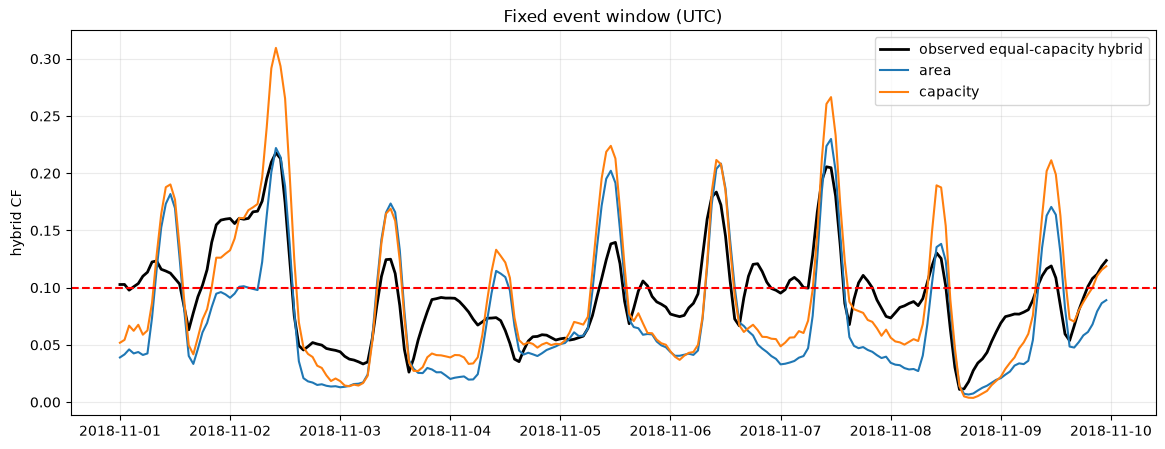

n  observed_mean  model_mean  correlation  \
area     wind    216.0         0.1409      0.0921       0.4876   
         solar   216.0         0.0462      0.0539       0.9785   
         hybrid  216.0         0.0936      0.0730       0.7391   
capacity wind    216.0         0.1409      0.1266       0.5506   
         solar   216.0         0.0462      0.0545       0.9793   
         hybrid  216.0         0.0936      0.0906       0.8110   

                 bias_model_minus_observed     mae    rmse  
area     wind                      -0.0488  0.0677  0.0794  
         solar                      0.0077  0.0102  0.0199  
         hybrid                    -0.0206  0.0368  0.0421  
capacity wind                      -0.0144  0.0590  0.0702  
         solar                      0.0083  0.0101  0.0203  
         hybrid                    -0.0030  0.0330  0.0394

In [10]:
win=aligned[aligned.interval_start_utc.between('2018-11-01','2018-11-09 23:00')]
fig,ax=plt.subplots(figsize=(14,5)); ax.plot(win.interval_start_utc,win.observed_hybrid_cf,label='observed equal-capacity hybrid',c='black',lw=2); ax.plot(win.interval_start_utc,win.hybrid_cf_area,label='area'); ax.plot(win.interval_start_utc,win.hybrid_cf_capacity,label='capacity'); ax.axhline(.10,c='red',ls='--'); ax.set(ylabel='hybrid CF',title='Fixed event window (UTC)'); ax.grid(alpha=.25); ax.legend(); plt.show()
pd.concat({w:pd.DataFrame(x).T for w,x in vqc['event_window_2018_11_01_through_09'].items()}).round(4)

## Limitations and conclusion

This is one nationally aggregated month with no plant-level observations. The conversion uses generic turbine/PV assumptions; COSMO is a reanalysis proxy, and SMARD/ENTSO-E generation can reflect curtailment, availability, reporting, and other operational effects. End-year capacity denominators are static. OPSD plant locations are spatial weights—not independent generation validation—and its time-series package is not used as a second independent reference because provenance may overlap. There is no independent OPSD generation validation.

Hourly observations support timing, ramp, daylight, and low-output classification checks, while the daily-route comparison shows what temporal resolution changes. The hypothetical equal-capacity hybrid supports resource screening only, not adequacy or shortage claims.